# Chicago Open Data → SQLite with pandas & JupySQL

![Python](https://img.shields.io/badge/Python-3776AB?logo=python&logoColor=white)
![SQLite](https://img.shields.io/badge/SQLite-003B57?logo=sqlite&logoColor=white)
![pandas](https://img.shields.io/badge/pandas-150458?logo=pandas&logoColor=white)
![Jupyter](https://img.shields.io/badge/Jupyter-F37626?logo=jupyter&logoColor=white)

> **Goal:** build a small relational database in Python from three public City of Chicago
> datasets and explore it with plain SQL inside a Jupyter notebook.

## Tools

| Tool | Role in this project |
|---|---|
| **SQLite** (`sqlite3`) | File-based SQL database engine, no server needed |
| **pandas** | Reads the CSV data and writes it to SQLite with `DataFrame.to_sql()` |
| **JupySQL** (`%sql`) | Runs SQL queries directly in notebook cells |

## Data sources

| Table | Dataset | Category | ID | Rows loaded |
|---|---|---|---|---|
| `chicago_crimes` | Crimes 2001 to Present | Public Safety | ijzp-q8t2 | 1000 (sample) |
| `chicago_schools` | Chicago Public Schools Progress Report Cards | Education |9xs2-f89t | 566 |
| `chicago_census` | Census Data Selected socioeconomic indicators | Health & Human Services | kn9c-c2s2 | 78 |

Source: [Chicago Data Portal](https://data.cityofchicago.org/). The crimes dataset has
~8.65 M rows (as of 2026-10-06), so only a sample is loaded here.






## ¿“How to get the CSV API endpoint?
>**Nota: Puedes descargar el .csv y agregar la ruta local, por cuestiones prácticas se llevó a cabo de esta manera.


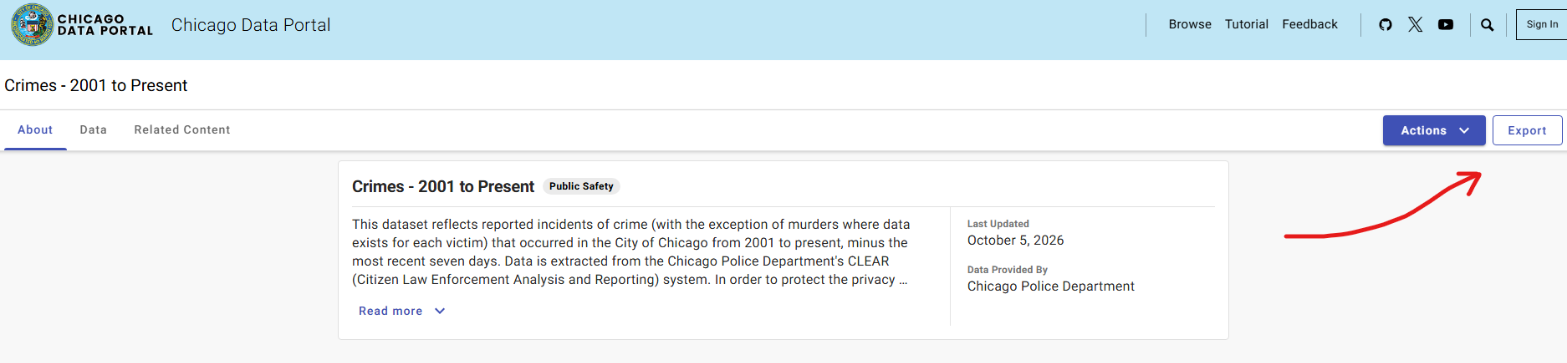

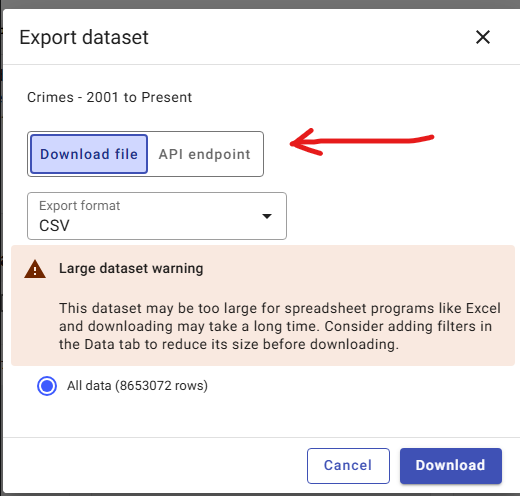

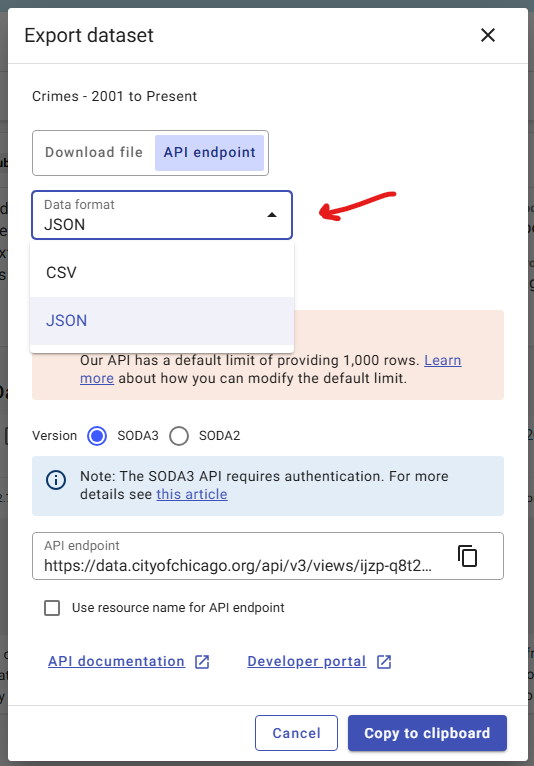

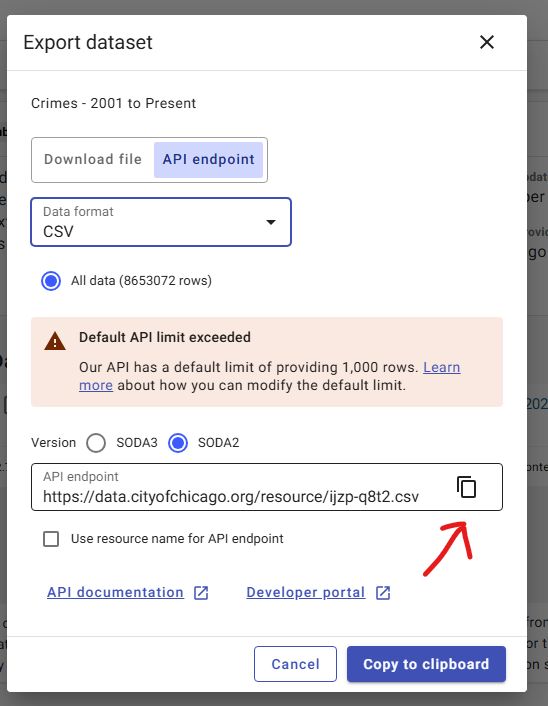


## Installation and import

In [1]:
# Install libraries in case they are not already installed
# If you are on Google Colab replace ! > %
#!pip install ipython-sql
#!pip install pandas
#!pip install prettytable
#!pip install jupysql

In [2]:
import prettytable 
import pandas as pd
import sqlite3

## Connection & load to data base

In [3]:
conn = sqlite3.connect("chicago.db")
prettytable.DEFAULT = 'DEFAULT'

In [4]:
%load_ext sql

1. Store the data from the `.CSV` file in the variable `df1`, which refers to **DataFrame1**.
2. Convert the DataFrame to SQL, name the table, and use the SQLite3 database `chicago.db`, stored in the `conn` variable, as the reference database.
3. Repeat the previous steps for the subsequent datasets.


In [5]:
df1 = pd.read_csv("https://data.cityofchicago.org/resource/9xs2-f89t.csv")
df1.to_sql("chicago_schools", conn, if_exists='replace', index=False)

566

In [6]:
df2 = pd.read_csv("https://data.cityofchicago.org/resource/kn9c-c2s2.csv") 
df2.to_sql("chicago_census", conn, if_exists='replace', index=False)

78

For the "Crimes" DATASET, a limit of 1,000 records (`?$limit=1000`) was set to avoid accessing all records, since there are currently **8,653,072 records**. You can try using as many records as you consider necessary.


In [7]:
df3 = pd.read_csv("https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=1000")
df3.to_sql("chicago_crimes", conn, if_exists='replace', index=False)

1000

Connecting MAGIC SQL to the database we have in `SQLITE3`.


In [8]:
%sql sqlite:///chicago.db

## QUERY & ANALYSIS
 Example of a query: 
` %sql SELECT * FROM Chicago_census `

1. Find column name and data type from `Chicago_crimes`

In [9]:
%sql PRAGMA table_info(chicago_crimes);

 * sqlite:///chicago.db
Done.


cid,name,type,notnull,dflt_value,pk
0,id,INTEGER,0,None,0
1,case_number,TEXT,0,None,0
2,date,TEXT,0,None,0
3,block,TEXT,0,None,0
4,iucr,TEXT,0,None,0
5,primary_type,TEXT,0,None,0
6,description,TEXT,0,None,0
7,location_description,TEXT,0,None,0
8,arrest,INTEGER,0,None,0
9,domestic,INTEGER,0,None,0


2. Find total number of crimes recorded in the `chicago_crimes` table

In [10]:
%sql SELECT COUNT(*) AS total_crimes_registered FROM chicago_crimes

 * sqlite:///chicago.db
Done.


total_crimes_registered
1000


3. Find minor crimes

In [11]:
%sql SELECT * FROM chicago_crimes WHERE `description` like '%minor%' limit 5

 * sqlite:///chicago.db
Done.


id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
14343500,JK432270,2026-09-29T18:16:00.000,050XX S COTTAGE GROVE AVE,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MINOR INJURY",PARKING LOT / GARAGE (NON RESIDENTIAL),1,0,223,2,20,38,08B,1182442.0,1871604.0,2026,2026-10-07T15:44:17.000,41.802896506,-87.606425428,", (41.802896506, -87.606425428)"
14345135,JK432208,2026-09-29T17:45:00.000,056XX S PEORIA ST,0440,BATTERY,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR INJURY",GAS STATION,0,0,712,7,16,68,08B,1171269.0,1867432.0,2026,2026-10-07T15:44:17.000,41.791700072,-87.647523744,", (41.791700072, -87.647523744)"
14343269,JK432191,2026-09-29T17:41:00.000,089XX S MUSKEGON AVE,0440,BATTERY,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR INJURY",PARK PROPERTY,0,0,423,4,7,46,08B,1196565.0,1846235.0,2026,2026-10-07T15:44:17.000,41.732942865,-87.555472437,", (41.732942865, -87.555472437)"
14343189,JK432145,2026-09-29T17:35:00.000,008XX N STATE ST,0440,BATTERY,"AGGRAVATED - HANDS, FISTS, FEET, NO / MINOR INJURY",CTA TRAIN,0,0,1832,18,42,8,08B,1176223.0,1905805.0,2026,2026-10-07T15:44:17.000,41.896888586,-87.628203192,", (41.896888586, -87.628203192)"
14342400,JK431144,2026-09-28T21:42:00.000,042XX W MONROE ST,0454,BATTERY,"AGGRAVATED P.O. - HANDS, FISTS, FEET, NO / MINOR INJURY",ALLEY,0,0,1115,11,28,26,08B,1148102.0,1899323.0,2026,2026-10-06T15:43:03.000,41.879689031,-87.731654537,", (41.879689031, -87.731654537)"


4. Find crimes that happened in schools

In [12]:
%sql SELECT * From Chicago_crimes WHERE `LOCATION_DESCRIPTION` LIKE '%SCHOOL%'

 * sqlite:///chicago.db
Done.


id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
14343889,JK432927,2026-09-29T16:00:00.000,060XX S PEORIA ST,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC GROUNDS,0,0,712,7,16,68,08B,1171341.0,1864917.0,2026,2026-10-07T15:44:17.000,41.784797052,-87.647333315,", (41.784797052, -87.647333315)"
14343188,JK432053,2026-09-29T15:30:00.000,081XX S CALIFORNIA AVE,0560,ASSAULT,SIMPLE,SCHOOL - PRIVATE GROUNDS,0,0,835,8,18,70,08A,1159127.0,1850529.0,2026,2026-10-07T15:44:17.000,41.745572921,-87.692508179,", (41.745572921, -87.692508179)"
14343133,JK432093,2026-09-29T15:20:00.000,062XX S HAMLIN AVE,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC GROUNDS,0,0,823,8,23,65,08B,1152108.0,1863143.0,2026,2026-10-07T15:44:17.000,41.780328363,-87.717896689,", (41.780328363, -87.717896689)"
14343578,JK432398,2026-09-29T14:45:00.000,049XX W 44TH ST,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC GROUNDS,0,0,814,8,22,56,08B,1143968.0,1875008.0,2026,2026-10-07T15:44:17.000,41.81304384,-87.747443268,", (41.81304384, -87.747443268)"
14343097,JK432078,2026-09-29T14:15:00.000,054XX W FULLERTON AVE,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC GROUNDS,0,0,2515,25,36,19,08B,1139841.0,1915427.0,2026,2026-10-07T15:44:17.000,41.924035234,-87.761594059,", (41.924035234, -87.761594059)"
14343466,JK432390,2026-09-29T14:00:00.000,067XX N WHIPPLE ST,5000,OTHER OFFENSE,OTHER CRIME AGAINST PERSON,SCHOOL - PUBLIC GROUNDS,0,0,2412,24,50,2,26,1154813.0,1944439.0,2026,2026-10-07T15:44:17.000,42.003358825,-87.705799818,", (42.003358825, -87.705799818)"
14343612,JK431722,2026-09-29T11:50:00.000,032XX S CALUMET AVE,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC BUILDING,0,0,211,2,4,35,08B,1179125.0,1883686.0,2026,2026-10-07T15:44:17.000,41.836126824,-87.618221478,", (41.836126824, -87.618221478)"
14343205,JK432183,2026-09-29T10:30:00.000,115XX S ADA ST,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC BUILDING,0,0,524,5,21,53,08B,1169402.0,1828225.0,2026,2026-10-07T15:44:17.000,41.684151193,-87.655501989,", (41.684151193, -87.655501989)"
14344085,JK433203,2026-09-29T10:00:00.000,044XX N BEACON ST,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC BUILDING,0,0,1913,19,46,3,08B,1166361.0,1929565.0,2026,2026-10-07T15:44:17.000,41.962304024,-87.663743043,", (41.962304024, -87.663743043)"
14343765,JK432754,2026-09-29T10:00:00.000,015XX W 95TH ST,0560,ASSAULT,SIMPLE,SCHOOL - PUBLIC GROUNDS,1,0,2213,22,21,73,08A,1167518.0,1841720.0,2026,2026-10-07T15:44:17.000,41.721224132,-87.662013664,", (41.721224132, -87.662013664)"


5. Find the column name and data type of `Chicago_schools`

In [13]:
%sql PRAGMA table_info(Chicago_schools);

 * sqlite:///chicago.db
Done.


cid,name,type,notnull,dflt_value,pk
0,school_id,INTEGER,0,None,0
1,name_of_school,TEXT,0,None,0
2,elementary_or_high_school,TEXT,0,None,0
3,street_address,TEXT,0,None,0
4,city,TEXT,0,None,0
5,state,TEXT,0,None,0
6,zip_code,INTEGER,0,None,0
7,phone_number,TEXT,0,None,0
8,link_,TEXT,0,None,0
9,network_manager,TEXT,0,None,0


6. Find the column name and data type of `Chicago_census`

In [14]:
%sql PRAGMA table_info(chicago_census)

 * sqlite:///chicago.db
Done.


cid,name,type,notnull,dflt_value,pk
0,ca,REAL,0,None,0
1,community_area_name,TEXT,0,None,0
2,percent_of_housing_crowded,REAL,0,None,0
3,percent_households_below_poverty,REAL,0,None,0
4,percent_aged_16_unemployed,REAL,0,None,0
5,percent_aged_25_without_high_school_diploma,REAL,0,None,0
6,percent_aged_under_18_or_over_64,REAL,0,None,0
7,per_capita_income_,INTEGER,0,None,0
8,hardship_index,REAL,0,None,0


7. List five community areas with the highest % of households below the poverty line.

In [15]:
%sql SELECT `Community_area_name`, `PERCENT_HOUSEHOLDS_BELOW_POVERTY` FROM Chicago_census ORDER BY `PERCENT_HOUSEHOLDS_BELOW_POVERTY` DESC LIMIT 5

 * sqlite:///chicago.db
Done.


community_area_name,percent_households_below_poverty
Riverdale,56.5
Fuller Park,51.2
Englewood,46.6
North Lawndale,43.1
East Garfield Park,42.4


## Close connection with the database

In [16]:
conn.close()
%sql -x / --close "sqlite:///chicago.db"